# Active Learning Reproduction Demo Experiment

This ```.ipynb``` notebook provides a demonstration of the experiments presented in the submitted
work. Section numbering in the notebook follows that of the paper.

First run through the ```Load and Process Data``` section to import utilities. Then for each section, experiments can be executed directly by running the corresponding code blocks (with optional adjustment of parameters as indicated). Alternatively, plots can be generated directly from stored experiment histories without rerunning the experiments.

---


## Load and Process Data

In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import torch
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from active_learning.train import train_model, tune_weight_decay
from active_learning.evaluate import evaluate
from active_learning.active_train_loop import acquire_point_indices, active_learning
from utils.data_process import split_dataset_indices
from models.cnn import CNN
from models.cnn_baseline import CNN_baseline

# Basic config
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda


In [12]:
# Load MNIST dataset with basic transforms
transform = transforms.Compose([
    transforms.ToTensor(),
])

full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
dataset_size = len(full_dataset)
print("Dataset size:", dataset_size)

Dataset size: 60000


In [13]:
# Check the implementation of a method that splits indices into train / pool / val / test

from utils.data_process import split_dataset_indices
splits = split_dataset_indices(
    full_dataset,
    split_size = (20, 100, 10000),
    seed = 42
)


Check if the classes are balance in the training split.

Total initial training samples: 20

Class distribution:
  Class 0: 2 samples
  Class 1: 2 samples
  Class 2: 2 samples
  Class 3: 2 samples
  Class 4: 2 samples
  Class 5: 2 samples
  Class 6: 2 samples
  Class 7: 2 samples
  Class 8: 2 samples
  Class 9: 2 samples


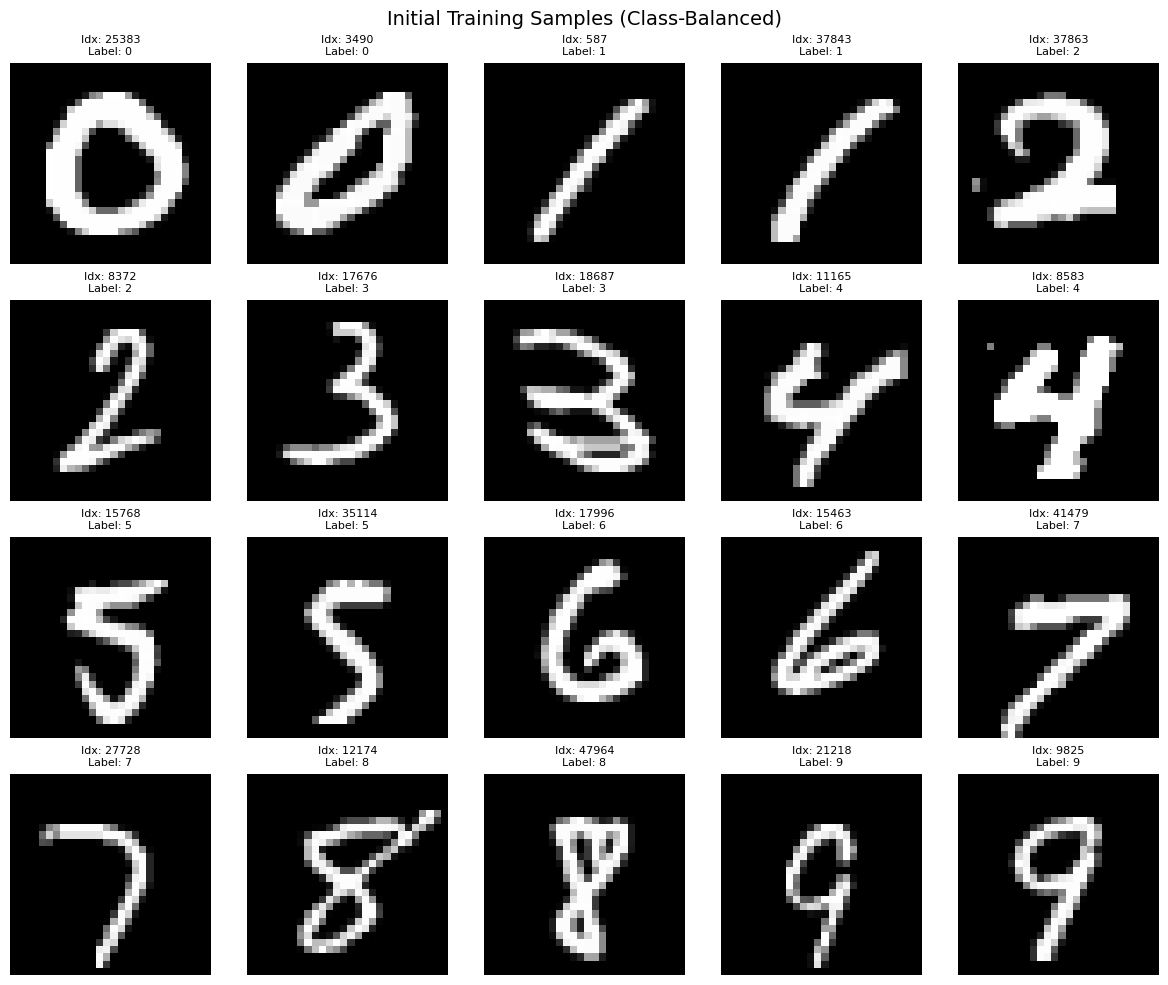

In [14]:
import matplotlib.pyplot as plt
import numpy as np

train_indices = splits["train"]
print(f"Total initial training samples: {len(train_indices)}")

label_counts = {}
for idx in train_indices:
    _, label = full_dataset[idx]
    label = int(label)
    label_counts[label] = label_counts.get(label, 0) + 1

print("\nClass distribution:")
for label in sorted(label_counts.keys()):
    print(f"  Class {label}: {label_counts[label]} samples")

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
fig.suptitle('Initial Training Samples (Class-Balanced)', fontsize=14)

for i, idx in enumerate(train_indices):
    row = i // 5
    col = i % 5
    img, label = full_dataset[idx]

    if isinstance(img, torch.Tensor):
        img_np = img.squeeze().cpu().numpy()  # [H, W]
    else:
        img_np = np.array(img).squeeze()
    
    axes[row, col].imshow(img_np, cmap='gray')
    axes[row, col].set_title(f'Idx: {idx}\nLabel: {int(label)}', fontsize=8)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

Load some existing training histories from ```Active Learning Accuracy Histories.csv```.

In [15]:
import pandas as pd
histories = pd.read_csv('Active Learning Accuracy Histories')
histories

,BALD_1,entropy_1,random_1,Var_ratios_1,mean_std_1,BALD_2,BALD_1_determ,Var_ratios_1_determ,BALD_2_determ,entropy_1_determ,...,mean_std_3,pred_cov_analytic_1_rmse,pred_cov_mfvi_1_rmse,random_1_rmse,pred_cov_analytic_2_rmse,pred_cov_mfvi_2_rmse,random_2_rmse,LAB2S_varrats_1,LAB2S_varrats_2,LAB2S_varrats_3
0,0.5260,0.5507,0.5623,0.5322,0.5313,0.5176,0.5056,0.5019,0.4924,0.5007,...,0.5263,0.261383,0.261370,0.265632,0.265283,0.265991,0.260213,0.5215,0.5437,0.5253
1,0.5960,0.6103,0.5545,0.6007,0.5743,0.6141,0.5488,0.5016,0.5636,0.5007,...,0.5515,0.257258,0.256862,0.249840,0.257395,0.253423,0.253138,0.6138,0.6355,0.5990
2,0.6205,0.6060,0.6193,0.5982,0.6382,0.6099,0.6138,0.5540,0.6362,0.5640,...,0.5882,0.254190,0.249732,0.238886,0.256635,0.253544,0.236032,0.6665,0.6430,0.6203
3,0.6466,0.5826,0.6747,0.6044,0.6113,0.5975,0.6162,0.5826,0.5945,0.5757,...,0.6259,0.253828,0.258112,0.231761,0.257029,0.249029,0.240168,0.6946,0.6838,0.6359
4,0.6629,0.6244,0.6942,0.6370,0.6927,0.6116,0.6044,0.6477,0.6401,0.5806,...,0.6127,0.248744,0.247609,0.232571,0.246143,0.248942,0.230092,0.6821,0.6760,0.6733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.9698,0.9712,0.9484,0.9804,0.9765,0.9659,0.9550,0.9442,0.9504,0.9399,...,0.9736,0.150239,0.190779,0.110274,0.124038,0.208754,0.109935,0.9736,0.9736,0.9760
96,0.9686,0.9749,0.9424,0.9782,0.9710,0.9676,0.9532,0.9459,0.9411,0.9398,...,0.9752,0.152639,0.194435,0.109685,0.124886,0.206812,0.108886,0.9750,0.9751,0.9755
97,0.9666,0.9772,0.9497,0.9811,0.9783,0.9650,0.9517,0.9433,0.9522,0.9288,...,0.9786,0.149344,0.189638,0.109747,0.129681,0.205732,0.107571,0.9733,0.9750,0.9744
98,0.9670,0.9756,0.9524,0.9708,0.9768,0.9642,0.9504,0.9433,0.9522,0.9421,...,0.9777,0.153107,0.192406,0.110212,0.126968,0.207327,0.105333,0.9744,0.9743,0.9761


Define some helper functions to help store new training history, or to plot history results with std. error, etc.

In [16]:
def store(hist, name, df, overwrite = False):
    '''
    Store a new accuracy history to a given dataframe, as a series with particular name.
    '''
    if name in df.columns and not overwrite:
        print(f"Saving aborted: Column '{name}' already exists in the dataframe, please use a different name. \nTo overwrite, use overwrite = True")
        return df
    df[name] = hist
    return df


def plot_mean_std(histories, keys, label, color, alpha_line=0.6, alpha_fill=0.15):
    '''
    Plot the mean and std of the given keys of histories.
    '''
    curves = np.array([histories[k] for k in keys])  # shape [num_runs, num_rounds] 
    mean = curves.mean(axis=0)
    std = curves.std(axis=0)

    x = np.arange(len(mean))

    if len(keys) == 1:
        plt.plot(x, mean, label=label, color=color, alpha=alpha_line)
    else:
        plt.fill_between(
            x,
            mean - std,
            mean + std,
            color=color,
            alpha=alpha_fill
        )
        plt.plot(x, mean, label=label, color=color, alpha=alpha_line)

def first_exceed_index(seq, threshold):
    """
    Return the first index i where seq[i] > threshold.
    If no such index, return None.
    """
    for i, v in enumerate(seq):
        if v > threshold:
            return i
    return None

## Section 3.1: Active Learning on MNIST, Comparison of various acquisition functions

This section reproduces the first experiment in Section 3 of the work. In each acquisition round, we use various acquisition functions ```entropy, BALD, mean_std, variation_ratio``` to score points in the pool set (with / without MC-dropout), and acquire points with the top scores. Their learning performance is compared with random acquisition ```random```.


Implement active learning with different acquisition functions ```entropy, BALD, variation_ratio, mean_std, random```. Since MC_dropout is used to sample from posterior during both acquisition and test time, use ```MC_acquire = True```, ```MC_test = True```.

In [ ]:
from active_learning.active_train_loop import active_learning

model, history = active_learning(
    dataset = full_dataset,
    acquisition_fn = "BALD",  # "entropy", "BALD", "variation_ratio", "mean_std", "random"
    split_size = (20, 100, 10000),
    random_split = True,
    model_class = CNN,
    weight_decay_candidates = [0.000001, 0.00001, 0.0001],
    n_rounds = 100,
    K = 10,
    T = 20,
    MC_acquire = True,
    MC_test = True
)

Store the new history.

In [ ]:
store(history, 'BALD_2', histories)
histories.to_csv('Active Learning Accuracy Histories', index = False)

Plot some existing histories (3 histories have been stored for each acquisition function). This plots Figure 1 in the report.

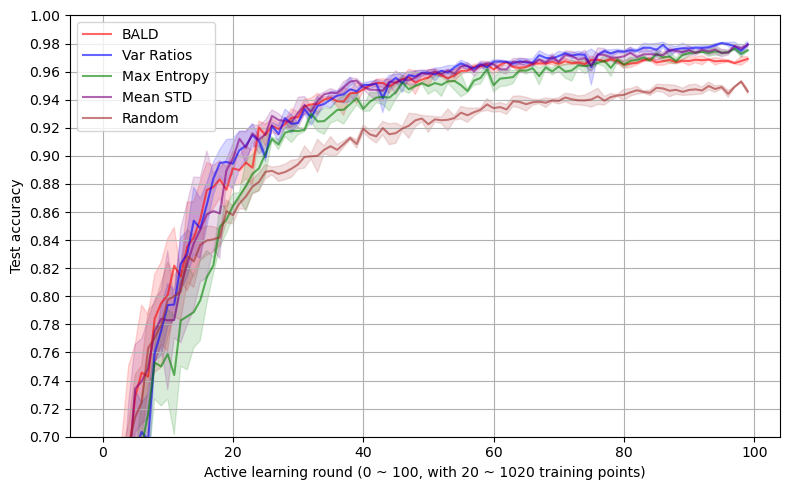

In [17]:
plt.figure(figsize=(8, 5))

plot_mean_std(
    histories,
    keys=['BALD_1', 'BALD_2', 'BALD_3'],
    label='BALD',
    color='red'
)

plot_mean_std(
    histories,
    keys=['Var_ratios_1', 'Var_ratios_2', 'Var_ratios_3'],
    label='Var Ratios',
    color='blue'
)

plot_mean_std(
    histories,
    keys=['entropy_1', 'entropy_2', 'entropy_3'],
    label='Max Entropy',
    color='green'
)

plot_mean_std(
    histories,
    keys=['mean_std_1', 'mean_std_2', 'mean_std_3'],
    label='Mean STD',
    color='purple'
)

plot_mean_std(
    histories,
    keys=['random_1', 'random_2', 'random_3'],
    label='Random',
    color='brown'
)

plt.xlabel("Active learning round (0 ~ 100, with 20 ~ 1020 training points)")
plt.ylabel("Test accuracy")
plt.ylim(0.7, 1.0)
plt.yticks(np.arange(0.7, 1.01, 0.02))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
acq_names = ['BALD', 'Var_ratios', 'entropy', 'mean_std', 'random']

for name in acq_names:
    mean_hist = (histories[name + '_1'] + histories[name + '_2'] + histories[name + '_3'])/3
    idx_90 = first_exceed_index(mean_hist, 0.90) * 10 + 5   # Since active_learning uses K=10 images per acquisition
    idx_95 = first_exceed_index(mean_hist, 0.95) * 10 + 5
    print(f"{name}: Accuracy >0.90 after acquiring {idx_90} images, >0.95 after {idx_95} images.")

BALD: Accuracy >0.90 after acquiring 245 images, >0.95 after 415 images.
Var_ratios: Accuracy >0.90 after acquiring 215 images, >0.95 after 405 images.
entropy: Accuracy >0.90 after acquiring 255 images, >0.95 after 465 images.
mean_std: Accuracy >0.90 after acquiring 215 images, >0.95 after 385 images.
random: Accuracy >0.90 after acquiring 335 images, >0.95 after 985 images.


## Section 3.2  Importance of model uncertainty

This section conducts the second experiment in Section 3 of the work, implementing active learning on **Deterministic CNN** (without MC dropout) using all acquisition functions. Additionally, we conduct an experiment also for ```mean_std```. Since MC dropout is neither activated during acquisition-score computations nor during test time, we simply switch to ```MC_acquire = False```, ```MC_test = False```.

Notice: turning MC_dropout off when computing acquisition functions theoretically should render ```BALD``` and ```mean_std``` useless (all scores will be approximately zero), even though a degraded performance is only observed with ```mean_std```.

In [ ]:
model, history = active_learning(
    dataset = full_dataset,
    acquisition_fn = "BALD",  # "entropy", "BALD", "variation_ratio", "mean_std", "random"
    split_size = (20, 100, 10000),
    random_split = True,
    model_class = CNN,
    weight_decay_candidates = [0.000001, 0.00001, 0.0001],
    n_rounds = 100,
    K = 10,
    T = 20,
    MC_acquire = False,
    MC_test = False
)


In [ ]:
store(history, 'mean_std_1_determ', histories) 
histories.to_csv('Active Learning Accuracy Histories', index = False)

We make an observe that for any of the above model trained with ```MC_acquire = False```, ```MC_test = False```, simplying setting ```mc_dropout = True``` in the evaluate method below improves upon their test-time performance by 2-3% compared with setting ```mc_dropout = False```! In particular, the standard dropout (weight scaling) during inference time (multiplying each $W_i$ by $p_i$) does not approximate the MC dropout very well. 

In [ ]:
test_indices = splits["test"]
acc = evaluate(model, full_dataset, test_indices, mc_dropout = True)
print(f'Test Accuracy: {acc}.')

To confirm and offer a fair comparison of the issue, we conduct the described atblation experiment with ```MC_acquire = False, MC_test = True```. That is, we acquire points in an epistemic-uncertainty-unaware fashion, but we test the model using MC dropout. We call these models **Semi-deterministic CNNs**. 

In [ ]:
model, history = active_learning(
    dataset = full_dataset,
    acquisition_fn = "mean_std",  # "entropy", "BALD", "variation_ratio", "mean_std", "random"
    split_size = (20, 100, 10000),
    random_split = True,
    model_class = CNN,
    weight_decay_candidates = [0.000001, 0.00001, 0.0001],
    n_rounds = 100,
    K = 10,
    T = 20,
    MC_acquire = False,
    MC_test = True
)

In [ ]:
store(history, 'mean_std_1_determ_testMC', histories) 
histories.to_csv('Active Learning Accuracy Histories', index = False)

Now we can plot Figure 2 in the original paper. Select the type of acquisition function below and click run.

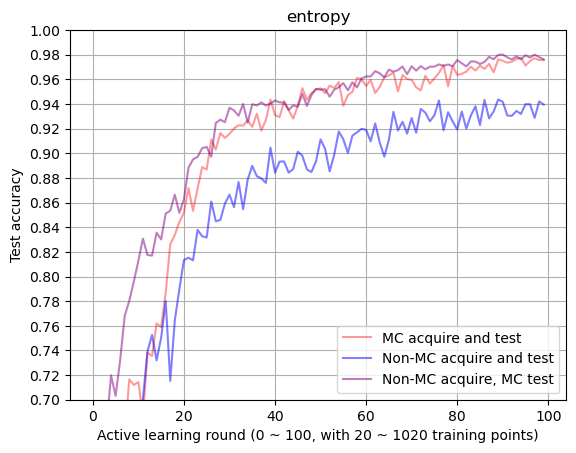

In [19]:
type = 'entropy'    # Select between 'BALD', 'Var_ratios', 'entropy', 'mean_std', 'random'

hist_mc = histories[type+'_1']  # History of model with MC_aquire = True, MC_test = True
hist_determ = histories[type+'_1_determ']  # History of model with MC_acquire = False, MC_test = False
hist_determ_testMC = histories[type+'_1_determ_testMC']  # History of model with MC_acquire = False, MC_test = True

plt.plot(hist_mc, label = 'MC acquire and test', c = 'red', alpha = 0.4)
plt.plot(hist_determ, label = 'Non-MC acquire and test', c = 'blue', alpha = 0.5)
plt.plot(hist_determ_testMC, label = 'Non-MC acquire, MC test', c = 'purple', alpha = 0.5)
plt.title(type)
plt.xlabel("Active learning round (0 ~ 100, with 20 ~ 1020 training points)")
plt.ylabel("Test accuracy")
plt.ylim(0.7, 1.0)
plt.yticks(np.arange(0.7, 1.01, 0.02))
plt.grid(True)
plt.legend()
plt.show()


Compare purple and blue: given that the model is trained using dropout, MC dropout during test time leads to significantly better performance than using standard dropout. This is regardless of whether the model is trained with MC-dropout-acquired data. This proves the significance of uncertainty during inference time. To explain this mathematically, in particular, standard dropout during inference time (multiplying each $W_i$ by $p_i$) does not approximate the MC-dropout very well, as expectation can not pass through non-linear layers...

Comparing red and purple: using uncertainty-aware acquisitions, in general we need fewer labeled samples to help model achieve certain test accuracy threshold, i.e. uncertainty is important in acquisition. However, epistemic uncertainty is not very important during acquisition (red and purple performance approximately same).



## Section 4. Baseline Comparison with Analytic (/MFVI) inference.

This section conducts the minimal extension of last-layer analytic / MFVI inference on active learning, treating the classification task as a regression task. In each acquisition round, unlabelled data from the pool with the highest predictive covariance are acquired. The predictive variance are calculated using 2 different approaches: Analytic inference ```pred_cov_analytic```, ```pred_cov_mfvi```. Their resulting learning performance is compared with random acquisition ```random```.

In [ ]:
from active_learning.active_train_loop_baseline import active_learning_baseline

model, history = active_learning_baseline(
    dataset=full_dataset,
    acquisition_fn="random", # Select between "pred_cov_analytic", "pred_cov_mfvi", "random"
    split_size=(20, 100, 10000),
    random_split=True,
    n_rounds=100,
    K=10,
    s_sq = 10,
    num_iterations = 50,
    lr = 0.001,
)

In [ ]:
test_indices = splits["test"]
acc = evaluate(model, full_dataset, test_indices, mc_dropout = False)
print(f'Test Accuracy: {acc}.')

For fair comparison, we also test the final test accuracy (not only RMSE) for the baseline models (training viewing the last layer as regression). In computing accuracy, we simply output the highest-value class as the predicted class.

* For pred_cov_analytic_1_rmse inference (s_sq = 2/128), the final RMSE is around 0.150, and the test accuracy is 0.9233.
* For pred_cov_analytic_2_rmse inference (s_sq = 10), the final RMSE is around 0.127, and the test accuracy is 0.965.
* For pred_cov_mfvi_1_rmse inference (s_sq = 2/128), the final RMSE is around 0.193, and the test accuracy is 0.8021.
* For pred_cov_mfvi_2_rmse inference (s_sq = 10), the final RMSE is around 0.2163, and the test accuracy is 0.7052.
* For random_1_rmse inference, the final RMSE is around 0.110, and the test accuracy is 0.967.
* For random_2_rmse inference, the final RMSE is around 0.109, and the test accuracy is 0.9637

The larger the scale of ```s_sq```, the wider the prior.

In [ ]:
store(history, 'random_2_rmse', histories, overwrite=True) 
histories.to_csv('Active Learning Accuracy Histories', index = False)

In [ ]:
histories

Plot Figure 3 in the report

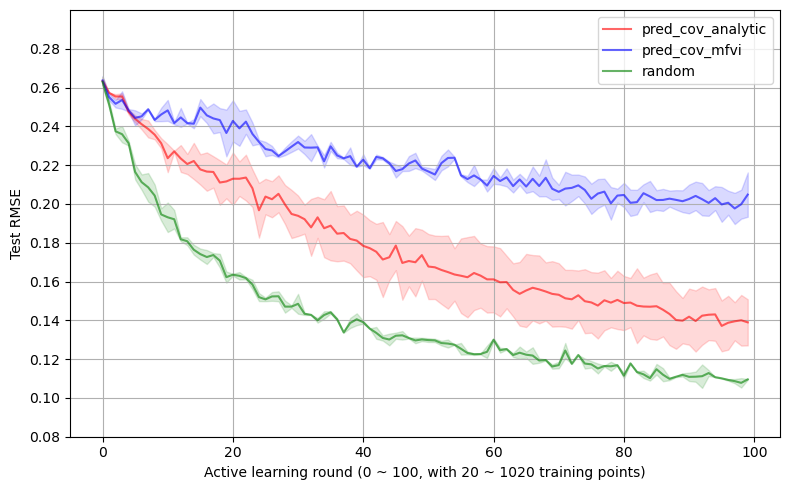

In [20]:
plt.figure(figsize=(8, 5))

plot_mean_std(
    histories,
    keys=['pred_cov_analytic_1_rmse', 'pred_cov_analytic_2_rmse'],
    label='pred_cov_analytic',
    color='red'
)

plot_mean_std(
    histories,
    keys=['pred_cov_mfvi_1_rmse', 'pred_cov_mfvi_2_rmse'],
    label='pred_cov_mfvi',
    color='blue'
)

plot_mean_std(
    histories,
    keys=['random_1_rmse', 'random_2_rmse'],
    label='random',
    color='green'
)

plt.xlabel("Active learning round (0 ~ 100, with 20 ~ 1020 training points)")
plt.ylabel("Test RMSE")
plt.ylim(0.08, 0.30)
plt.yticks(np.arange(0.08, 0.30, 0.02))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Interestingly, random acquisition beats both ```pred_cov_analytic``` and ```pred_cov_mfvi```. 

## Section 5: Further Extension - Langevin-based Adaptive Basis Selective Sampling (LAB2S)

Instead of treating final layer as a regression task, one can view it still as classfication task. Train a model (with weight decay), then freeze all layers up to the last layer and use the network as a feature extractor. Starting from the trained optimal parameters of the last layer, independently run SGD to train $T$ heads, and treat the models obtained from SGD sampling as posterior samples. Note that the SGD objective should include the same weight decay as in the original model. The initial learning rate $\alpha_0 (= 1.0)$ can be specified manually, and the subsequent learning rate follow a Robbins–Monro type schedule $\alpha_s = \alpha_0 / (10s + 1000)$. Finally, these $T$ heads are attached back to the feature extractor and regard them as $T$ posterior-sampled models, which are then used to compute the prediction probability vector for each data point in the pool set.

The above design is supported by 3 major reasons:  
* it captures the epistemic uncertainty in prediction resulting from high feature multi-collinearity in the last layer features.
* it is not a variational approach. Without assuming a specific form of the weight posterior, this method derived from SGLD results in a more faithful representation of the posterior.
* it is computationally feasible and provably stable due to the log-concavity of the loss landscape.


1. There are severe multi-collinearity between the 128 learned features, which results in high uncertainty in final layer's weight estimation (generalizing a standard fact from linear regression), leading to epistemic uncertainty in prediction. Capturing the uncertainty within the weight learning process allows us to quantify the epistemic uncertainty in predictions.

To see the multi-collinearity, we train a ```cnn_baseline``` and compute the **Variance Inflation Factor (VIF)** for each of its penultimate layer's 128 features. VIF measures how much the variance of a feature's coefficient increases due to collinearity with others, and is defined as $1/(1-r^2)$, where $r^2$ is the $r^2$ coef. of regressing this feature against the rest. The following code produces the histogram of VIFs.

Training Complete. Test Accuracy: 0.7418
Computing VIF for feature 0...
Computing VIF for feature 10...
Computing VIF for feature 20...
Computing VIF for feature 30...
Computing VIF for feature 40...
Computing VIF for feature 50...
Computing VIF for feature 60...
Computing VIF for feature 70...
Computing VIF for feature 80...
Computing VIF for feature 90...
Computing VIF for feature 100...
Computing VIF for feature 110...
Computing VIF for feature 120...


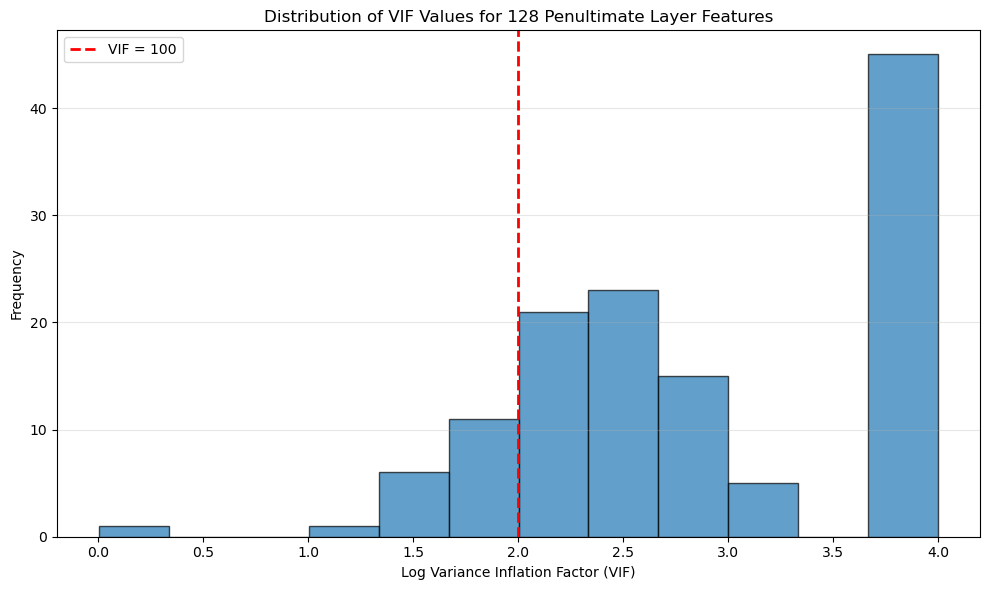

Features with VIF>10: 127. Min VIF: 1.0108170552531506, Max VIF: 10000.0


In [21]:
# Train CNN_baseline and compute VIF for penultimate layer features
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from models.cnn_baseline import CNN_baseline
from active_learning.train import train_model, tune_weight_decay

val_indices = splits["val"]
test_indices = splits["test"]

# Train model
model = train_model(CNN_baseline, full_dataset, val_indices, 0.0001,
                    num_epochs=100, criterion='accuracy', device=DEVICE)
print(f"Training Complete. Test Accuracy: {evaluate(model, full_dataset, test_indices, mc_dropout=False):.4f}")

# Extract features from full_dataset
model.eval()
features_list = []
with torch.no_grad():
    loader = torch.utils.data.DataLoader(full_dataset, batch_size=64, shuffle=False)
    for images, _ in loader:
        features_list.append(model.get_feature(images.to(DEVICE)).cpu())
features = torch.cat(features_list, dim=0).numpy()

# Extract: Compute VIF for each feature
features_std = (features - features.mean(axis=0)) / (features.std(axis=0) + 1e-8)
vifs = np.zeros(128)
for i in range(128):
    y = features_std[:, i]
    X = np.delete(features_std, i, axis=1)
    if i % 10 == 0:
        print(f'Computing VIF for feature {i}...')
    r_squared = LinearRegression(fit_intercept=False).fit(X, y).score(X, y)
    vifs[i] = 1.0 / (1.0 - r_squared) if r_squared < 0.9999 else 10000
log_vifs = np.log10(vifs)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(log_vifs, bins=12, edgecolor='black', alpha=0.7)
plt.axvline(x = 2, color='r', linestyle='--', linewidth=2, label='VIF = 100')
plt.xlabel('Log Variance Inflation Factor (VIF)')
plt.ylabel('Frequency')
plt.title('Distribution of VIF Values for 128 Penultimate Layer Features')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Features with VIF>10: {np.sum(vifs > 10)}. Min VIF: {np.min(vifs)}, Max VIF: {np.max(vifs)}")




The above uncertainty can be captured by training SGDs, starting around the optimized last layer weights (MAP)

2. Adopting an SGLD-based approach (SGD is similar to SGLD), this offers a way to sample from the *exact* model posterior $p(W|\mathcal D)$, not having to carry out variational optimization (like ELBO) to fit a special parametrizable form as the *approximate* posterior, which offers huge advantage. We note the previous mfvi and analytic inference methods on the last layer did not perform well due to their unrealistic assumption about the posterior form for the layer weights (e.g. independence and etc.), as well as their assumption made about the output distribution $p(y|\phi, w) $, which none is needed for SGD-based approach on final layer.

3. There are theoretical justifications for carrying out uncertainty inference only on the last layer. The SGD training on last layer is not heavy compared with full-network SGD. Moreover, since the likelihood landscape $p(w|\mathcal D) \propto p(\mathcal D|w) p(W)$ is log-concave, the Robbins-Monro type schedule for SGD on the log-space enjoys stability. There are also additional theoretical justification for initiating SGD from local optimal (cold_start = False) to explore the posterior landscape...

In [ ]:
from active_learning.active_train_lastlayer import active_learning_lastlayer    

In [ ]:
model, history = active_learning_lastlayer(
    full_dataset,
    acquisition_fn="mean_std_heads", # var_rat_heads, (mean_std_heads,  BALD_heads under development)
    split_size=(20, 100, 10000),  # Initial_training, Validation, Test_set size
    random_split=False,
    weight_decay_candidates=[0.000001, 0.00001, 0.0001],
    n_rounds=100,
    K=10,
    T=10,  # Number of heads to train (posterior samples)
    alpha_0=0.01,  # Initial learning rate for Robbins-Monro schedule
    num_iterations=1000,  # Number of SGD iterations per head
    batch_size=64,
    device="cuda",
    cold_start = False,
    langevin = False
)

In [ ]:
store(history, 'LAB2S_varrats_3', histories, overwrite=False) 
histories.to_csv('Active Learning Accuracy Histories', index = False)

In [ ]:
histories

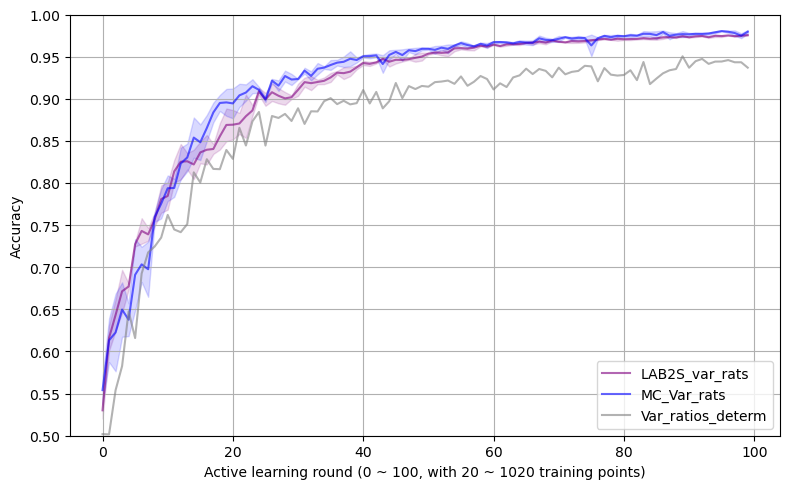

In [22]:
plt.figure(figsize=(8, 5))

plot_mean_std(
    histories,
    keys=['LAB2S_varrats_1', 'LAB2S_varrats_2', 'LAB2S_varrats_3'],
    label='LAB2S_var_rats',
    color='purple'
)

plot_mean_std(
    histories,
    keys=['Var_ratios_1', 'Var_ratios_2', 'Var_ratios_3'],
    label='MC_Var_rats',
    color='blue'
)

plot_mean_std(
    histories,
    keys=['Var_ratios_1_determ'],
    label='Var_ratios_determ',
    color='gray'
)



plt.xlabel("Active learning round (0 ~ 100, with 20 ~ 1020 training points)")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1)
plt.yticks(np.arange(0.5, 1.01, 0.05))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Last layer SGD produces good performance at the beginning since it captures the last-layer feature-usage (which learned features to use) level uncertainty well. Later in the training phase however (from 13th round onwards), deeper uncertainty (e.g. what features to learn) arising from earlier feature-extractor layers kick in, and LAB2S is slightly outperformed by the MC-dropout approach.

This points to a temporal uncertainty migration pattern, modelling uncertainty of a deep model architecture from output level gradually towards the input source as training progresses.